# Baseline Model Development

This notebook develops baseline machine learning models for predicting encapsulation efficiency from formulation features extracted during exploratory data analysis (notebook 01).

The distinction will be made between Model 1 and Model 2:
Model 1: df_final_num: numerical features only
Model 2: df_final_num_cat: numerical + 1 categorical feature: "Does ionizable lipid identity provide additional predictive power beyond formulation ratios alone?"

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 1. Model 1

### Load processed dataset, define X and Y, and train-test split

In [2]:
df_num = pd.read_csv(
    "../data/processed/df_final_num.csv"
)

X = df_num.drop(
    columns=["encapsulation_efficiency"]
)

y = df_num["encapsulation_efficiency"]

#80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=126
)

### Model 1.1: Linear Regression

In [3]:
model_lr = LinearRegression()

model_lr.fit(X_train,y_train)

y_pred = model_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test,y_pred)
print("MAE:",mae_lr)

r2_lr = r2_score(y_test, y_pred)
print("R2:", r2_lr) 

MAE: 13.361095497578367
R2: 0.11914744923145426


### Model 1.2: Random Forest

In [4]:
rf = RandomForestRegressor(random_state=126)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
print("MAE:",mae_rf)

r2_rf = r2_score(y_test,y_pred_rf)
print("R2:",r2_score(y_test,y_pred_rf))

MAE: 10.369649357802686
R2: 0.29940602762686164


# 2. Model 2

### Load processed dataset, define X and Y, and train-test split

In [5]:
df_num_cat = pd.read_csv(
    "../data/processed/df_final_num_cat.csv"
)

X2 = df_num_cat.drop(
    columns=["encapsulation_efficiency"]
)

y2 = df_num_cat["encapsulation_efficiency"]

#80% training and 20% testing
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=126
)

### Model 2.1: Linear Regression

In [6]:
model_lr2 = LinearRegression()

model_lr2.fit(X2_train,y2_train)

y2_pred = model_lr2.predict(X2_test)

mae_lr_2 = mean_absolute_error(y2_test, y2_pred)
print("MAE:", mae_lr_2)

r2_lr_2 = r2_score(y2_test, y2_pred)
print("R2:", r2_lr_2)

MAE: 11.250873668594915
R2: 0.3163053057122468


### Model 2.2: Random Forest

In [7]:
rf2 = RandomForestRegressor(random_state=126)

rf2.fit(X2_train,y2_train)

y2_pred_rf = rf2.predict(X2_test)

mae_rf_2 = mean_absolute_error(y2_test, y2_pred_rf)
print("MAE:", mae_rf_2)

r2_rf_2 = r2_score(y2_test, y2_pred_rf)
print("R2:", r2_rf_2)

MAE: 8.821159396282727
R2: 0.49263664318768163


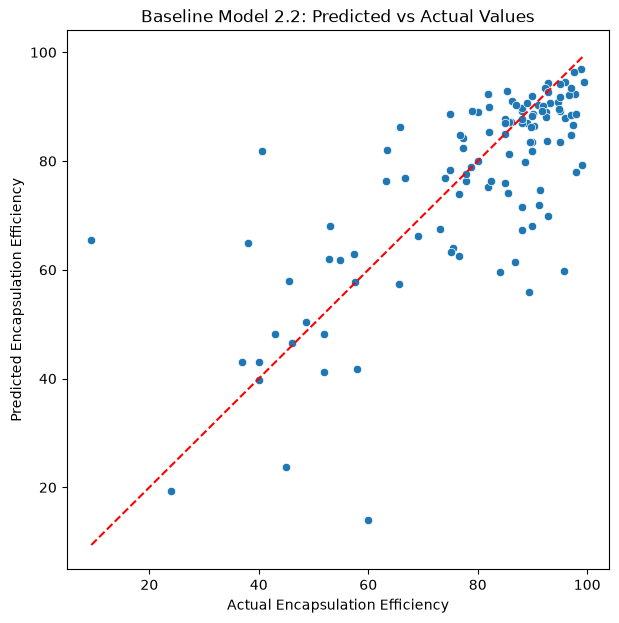

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,7))

sns.scatterplot(
    x=y_test,
    y=y2_pred_rf
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Encapsulation Efficiency")
plt.ylabel("Predicted Encapsulation Efficiency")
plt.title("Baseline Model 2.2: Predicted vs Actual Values")

plt.show()

In [9]:
results = pd.DataFrame({
    "Dataset": [
        "Numerical",
        "Numerical",
        "Numerical + Ionizable Lipid",
        "Numerical + Ionizable Lipid"
    ],
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_lr_2,
        mae_rf_2
    ],
    "R2": [
        r2_lr,
        r2_rf,
        r2_lr_2,
        r2_rf_2
    ]
})

results

,Dataset,Model,MAE,R2
0,Numerical,Linear Regression,13.361095,0.119147
1,Numerical,Random Forest,10.369649,0.299406
2,Numerical + Ionizable Lipid,Linear Regression,11.250874,0.316305
3,Numerical + Ionizable Lipid,Random Forest,8.821159,0.492637


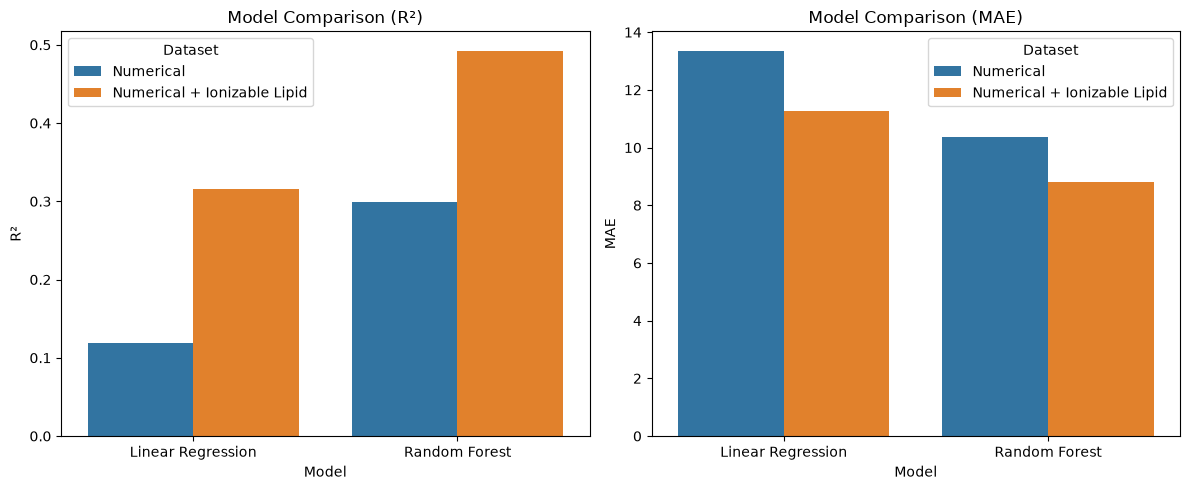

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R²
sns.barplot(
    data=results,
    x="Model",
    y="R2",
    hue="Dataset",
    ax=axes[0]
)

axes[0].set_title("Model Comparison (R²)")
axes[0].set_ylabel("R²")

# MAE
sns.barplot(
    data=results,
    x="Model",
    y="MAE",
    hue="Dataset",
    ax=axes[1]
)

axes[1].set_title("Model Comparison (MAE)")
axes[1].set_ylabel("MAE")

plt.tight_layout()
plt.show()

### Model Comparison

Random Forest outperformed Linear Regression across all feature sets, suggesting that non-linear relationships exist between formulation characteristics and encapsulation efficiency.

The inclusion of ionizable lipid identity substantially improved predictive performance. For the Random Forest model, the MAE decreased from 10.4% to 8.8%, while the R² increased from 0.30 to 0.49.

These findings indicate that ionizable lipid chemistry provides important information beyond formulation ratios and particle size alone.

In [20]:
#save model 2.2 as baseline
import joblib

joblib.dump(rf2,"../models/random_forest_baseline.pkl")
joblib.dump(list(X2_train.columns),"../models/feature_names.pkl") #save feature names

results.to_csv("../models/model_results.csv", index=False)

## Feature Importance of Baseline Model 2.2

In [12]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X2_train.columns,
    "Importance": rf2.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

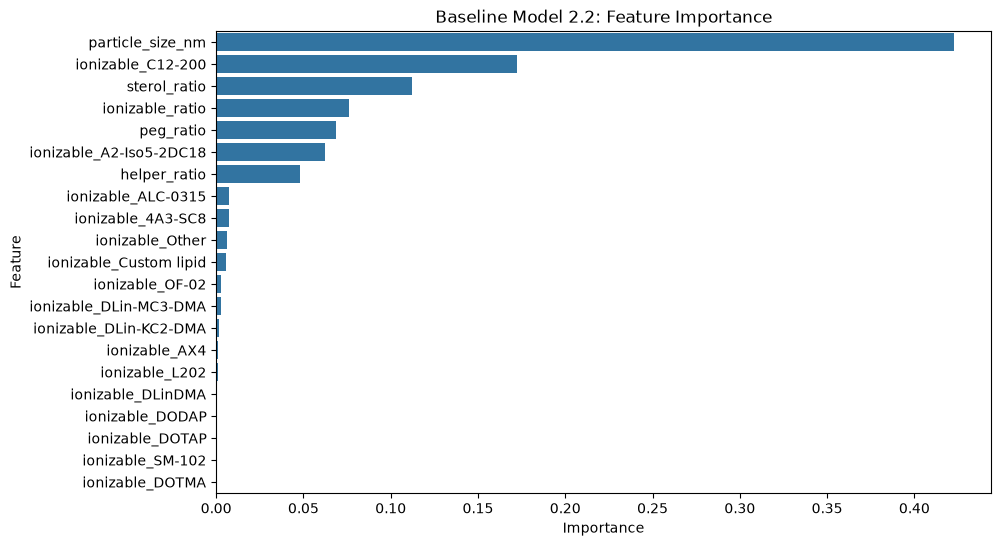

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Baseline Model 2.2: Feature Importance")
plt.show()

### Feature Importance Analysis

Feature importance scores were extracted from the Random Forest model to identify the variables that contributed most strongly to the prediction of encapsulation efficiency.

Particle size emerged as the most important predictor by a substantial margin. This finding suggests that particle size captures information that is strongly associated with encapsulation efficiency across the formulations included in the dataset.

Among the ionizable lipid categories, the presence of C12-200 was identified as an influential feature. This observation is consistent with the earlier exploratory analysis, which indicated that encapsulation efficiency distributions differed considerably between ionizable lipid classes.

The sterol ratio, ionizable lipid ratio, and PEG ratio also contributed to model predictions, although their importance was lower than that of particle size. Overall, the results suggest that both formulation composition and ionizable lipid identity influence encapsulation efficiency, with particle size acting as the strongest individual predictor within the current feature set.